# Notebook 4: Ablation Study
**Paper:** *Agents for Agents: An Interrogator-Based Secure Framework for Autonomous IoUT*

This notebook reproduces the ablation analysis from Section VI.E **using real simulation outputs** from `simulation/outputs/results.csv`.

| Config | Components | Metric source |
|---|---|---|
| A | Static Auth only | `results.csv` (static columns) |
| B | + Bayesian Trust Scoring | `results.csv` (bayesian columns) |
| C | + Transformer + Blockchain | `results.csv` (proposed columns) |

No hardcoded metric table is used in this notebook.

In [8]:
import subprocess, sys, os
from pathlib import Path

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'numpy', 'pandas', 'matplotlib'], check=True)

cwd = Path.cwd()
repo_root = None

candidates = [cwd, *cwd.parents]
# Prefer a repo root that already has results.csv
for candidate in candidates:
    if (candidate / 'simulation' / 'outputs' / 'results.csv').exists() and (candidate / 'analysis').exists():
        repo_root = candidate
        break

# Otherwise fall back to any repository-shaped folder
if repo_root is None:
    for candidate in candidates:
        if (candidate / 'simulation').exists() and (candidate / 'analysis').exists():
            repo_root = candidate
            break

if repo_root is None:
    clone_dir = cwd / 'IoUT-Interrogator-Framework'
    if not clone_dir.exists():
        subprocess.run(['git', 'clone', 'https://github.com/aliakarma/IoUT-Interrogator-Framework.git'], check=True)
    repo_root = clone_dir

os.chdir(repo_root)
sys.path.insert(0, str(repo_root))

# Always refresh existing clones in Colab so latest remote files are visible.
if (repo_root / '.git').exists():
    try:
        subprocess.run(['git', 'fetch', 'origin'], check=True)
        subprocess.run(['git', 'checkout', 'main'], check=True)
        subprocess.run(['git', 'pull', '--ff-only', 'origin', 'main'], check=True)
        print('Repository refreshed from origin/main.')
    except Exception as e:
        print(f'Warning: could not auto-update repo: {e}')

print(f'Ready. Repo root: {repo_root}')

Repository refreshed from origin/main.
Ready. Repo root: c:\Users\Ali Akarma\Desktop\Github\IoUT\IoUT-Interrogator-Framework


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from analysis.plot_ablation import load_ablation_data, plot_ablation
print('Imports OK.')

Imports OK.


In [7]:
# ── Cell 3: Ablation table (data-driven) ────────────────────────────────────
results_path = 'simulation/outputs/results.csv'

if not os.path.exists(results_path):
    print('results.csv not found. Running simulation to generate it...')
    subprocess.run([
        sys.executable, 'simulation/scripts/run_simulation.py',
        '--use-transformer', 'True',
        '--no-quantized-transformer',
        '--runs', '30',
        '--seed', '42',
        '--intervals', '20',
        '--output', results_path,
    ], check=True)
    print(f'Generated: {results_path}')

ablation_data = load_ablation_data(results_path)

accuracies = ablation_data['accuracy']
pdrs = ablation_data['pdr']

acc_delta_ab = accuracies[1] - accuracies[0]
acc_delta_bc = accuracies[2] - accuracies[1]
pdr_delta_ab = pdrs[1] - pdrs[0]
pdr_delta_bc = pdrs[2] - pdrs[1]

df = pd.DataFrame({
    'Config': ['A — Static Auth', 'B — + Bayesian Trust', 'C — + Transformer + BC'],
    'Accuracy (%)': [round(v, 2) for v in accuracies],
    'PDR (%)': [round(v, 2) for v in pdrs],
    'Acc Δ': ['—', f'+{acc_delta_ab:.2f} pp', f'+{acc_delta_bc:.2f} pp'],
    'PDR Δ': ['—', f'+{pdr_delta_ab:.2f} pp', f'+{pdr_delta_bc:.2f} pp'],
})
print(df.to_string(index=False))

                Config  Accuracy (%)  PDR (%)     Acc Δ    PDR Δ
       A — Static Auth          86.0    85.99         —        —
  B — + Bayesian Trust          99.2    89.43 +13.20 pp +3.44 pp
C — + Transformer + BC         100.0    93.35  +0.80 pp +3.92 pp


Saved figure: analysis/plots/ablation_study.png


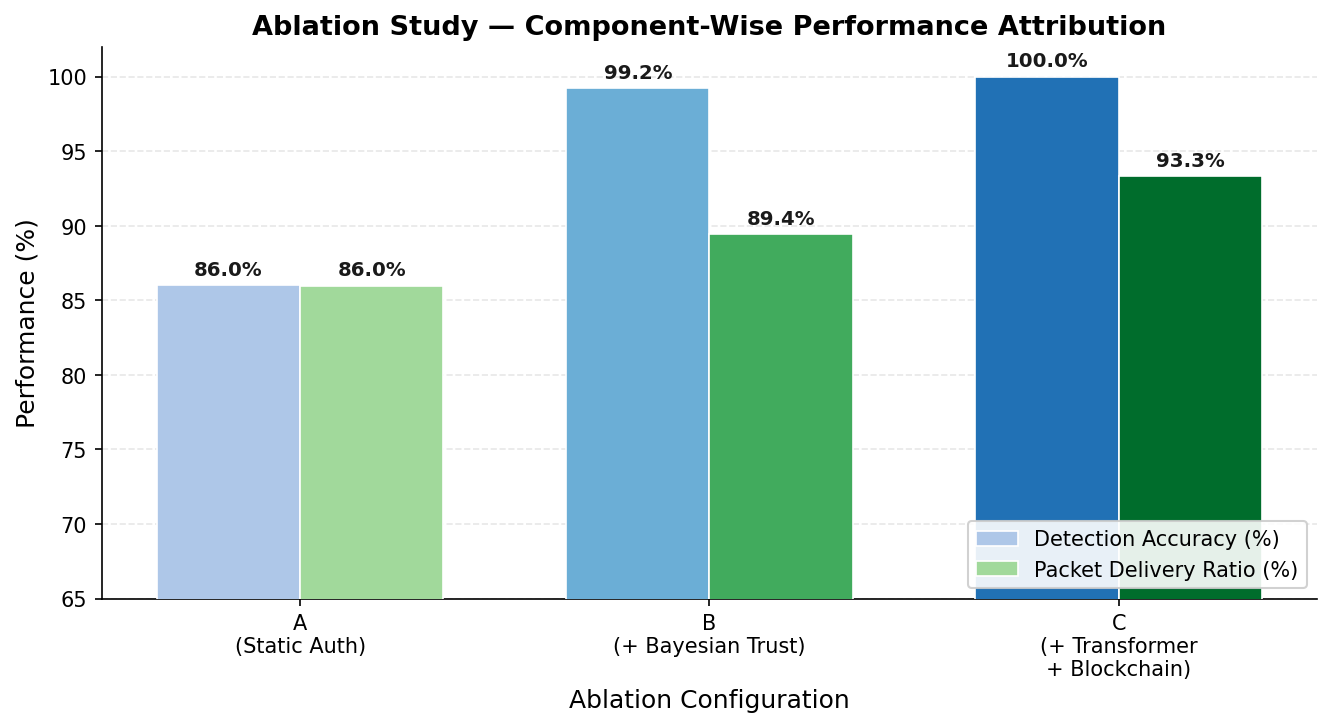

In [4]:
# ── Cell 4: Ablation bar chart ─────────────────────────────────────────────
os.makedirs('analysis/plots', exist_ok=True)
plot_ablation('simulation/outputs/results.csv', 'analysis/plots/ablation_study.png')
from IPython.display import Image
Image('analysis/plots/ablation_study.png')

In [5]:
# ── Cell 5: Component attribution analysis (from results.csv) ──────────────
configs = ablation_data['configs']
accuracies = ablation_data['accuracy']
pdrs = ablation_data['pdr']

print('=== Component Attribution ===')
print(f'\nA → B (adding Bayesian trust scoring):')
print(f'  Accuracy gain: +{accuracies[1]-accuracies[0]:.2f} pp  '
      f'({(accuracies[1]-accuracies[0])/accuracies[0]*100:.1f}% relative improvement)')
print(f'  PDR gain:      +{pdrs[1]-pdrs[0]:.2f} pp')

print(f'\nB → C (adding transformer inference + blockchain governance):')
print(f'  Accuracy gain: +{accuracies[2]-accuracies[1]:.2f} pp  '
      f'({(accuracies[2]-accuracies[1])/accuracies[1]*100:.1f}% relative improvement)')
print(f'  PDR gain:      +{pdrs[2]-pdrs[1]:.2f} pp')

print(f'\nTotal improvement (A → C):')
print(f'  Accuracy: +{accuracies[2]-accuracies[0]:.2f} pp ({(accuracies[2]-accuracies[0])/accuracies[0]*100:.1f}% relative)')
print(f'  PDR:      +{pdrs[2]-pdrs[0]:.2f} pp')

=== Component Attribution ===

A → B (adding Bayesian trust scoring):
  Accuracy gain: +13.20 pp  (15.3% relative improvement)
  PDR gain:      +3.44 pp

B → C (adding transformer inference + blockchain governance):
  Accuracy gain: +0.80 pp  (0.8% relative improvement)
  PDR gain:      +3.92 pp

Total improvement (A → C):
  Accuracy: +14.00 pp (16.3% relative)
  PDR:      +7.36 pp


In [6]:
# ── Cell 6: Horizontal metric view ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, metric, values, title, color in [
    (axes[0], 'Accuracy (%)', accuracies, 'Anomaly Detection Accuracy', '#2171b5'),
    (axes[1], 'PDR (%)',      pdrs,       'Packet Delivery Ratio',      '#2ca02c'),
]:
    bars = ax.barh(configs, values,
                   color=[f'{color}66', f'{color}aa', color],
                   edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, values):
        ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
                f'{val:.2f}%', va='center', fontsize=10, fontweight='bold')
    ax.set_xlabel(metric, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(60, 100)
    ax.grid(True, axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Ablation Study — Horizontal Performance View', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('analysis/plots/ablation_horizontal.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: analysis/plots/ablation_horizontal.png')

Saved: analysis/plots/ablation_horizontal.png


C:\Users\Ali Akarma\AppData\Local\Temp\ipykernel_17360\484121617.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
